# 07. Drzewo decyzyjne od zera: klasy, rekurencja i Gini

Cel: zakodować mały klasyfikator drzewa decyzyjnego **bez `DecisionTreeClassifier`**.

W tym notebooku implementujemy:

- liczenie Gini,
- sprawdzanie wszystkich kandydatów na podział,
- wybór najlepszego pytania,
- klasy `Split`, `Leaf`, `DecisionNode`,
- rekurencyjne budowanie drzewa,
- predykcję i wyjaśnienie ścieżki dla pojedynczego przykładu.

Dla prostoty implementacja obsługuje:

- cechy liczbowe przez pytania typu `cecha <= próg`,
- cechy kategoryczne przez pytania typu `cecha == wartość`.


Ten notebook jest najbardziej programistyczny w całej serii. Warto traktować go jako bonus: pokazuje, że `sklearn` nie jest magią, tylko implementacją znanych kroków.

In [1]:
from dataclasses import dataclass
from pathlib import Path
from typing import Any
import io
import contextlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

BASE = Path.cwd()
for candidate in [BASE, BASE.parent, Path("/mnt/data/drzewa_decyzyjne_dydaktyka")]:
    if (candidate / "data" / "06_zaliczenie_mini_recznie.csv").exists():
        BASE = candidate
        break
else:
    BASE = Path.cwd()

ASSETS = BASE / "assets"
ASSETS.mkdir(exist_ok=True)

csv_path = BASE / "data" / "06_zaliczenie_mini_recznie.csv"

if csv_path.exists():
    df = pd.read_csv(csv_path)
else:
    # Fallback dydaktyczny: małe dane z cechami liczbowymi i jedną kategorią.
    df = pd.DataFrame({
        "student_id": range(1, 21),
        "zadania_pkt":   [20, 35, 42, 48, 55, 60, 62, 70, 72, 78, 80, 85, 30, 45, 58, 66, 74, 88, 92, 50],
        "projekt_pkt":   [25, 30, 45, 52, 58, 55, 70, 68, 75, 80, 78, 90, 35, 40, 62, 72, 70, 85, 95, 57],
        "obecnosc_pct":  [50, 55, 62, 70, 75, 68, 82, 80, 88, 90, 76, 95, 58, 65, 72, 84, 86, 92, 98, 74],
        "aktywnosc":     ["niska", "niska", "srednia", "srednia", "srednia", "niska", "wysoka", "srednia", "wysoka", "wysoka", "srednia", "wysoka", "niska", "niska", "srednia", "wysoka", "srednia", "wysoka", "wysoka", "srednia"],
        "zaliczenie":    ["nie", "nie", "nie", "nie", "tak", "nie", "tak", "tak", "tak", "tak", "tak", "tak", "nie", "nie", "tak", "tak", "tak", "tak", "tak", "nie"],
    })

df


,student_id,zadania_pkt,projekt_pkt,obecnosc_pct,aktywnosc,zaliczenie
0,1,20,25,50,niska,nie
1,2,35,30,55,niska,nie
2,3,42,45,62,srednia,nie
3,4,48,52,70,srednia,nie
4,5,55,58,75,srednia,tak
5,6,60,55,68,niska,nie
6,7,62,70,82,wysoka,tak
7,8,70,68,80,srednia,tak
8,9,72,75,88,wysoka,tak
9,10,78,80,90,wysoka,tak


## 1. Dane

Każdy wiersz to student. Chcemy przewidzieć `zaliczenie`.

| Kolumna | Znaczenie |
|---|---|
| `zadania_pkt` | punkty za zadania |
| `projekt_pkt` | punkty za projekt |
| `obecnosc_pct` | obecność w procentach |
| `aktywnosc` | opisowa aktywność na zajęciach |
| `zaliczenie` | etykieta: `tak` albo `nie` |

To nadal są małe, fikcyjne dane dydaktyczne, ale są trudniejsze niż przykład z lodami, bo zawierają progi liczbowe.


## 2. Gini i kandydaci na podział

Dla cechy liczbowej kandydatami są progi między kolejnymi posortowanymi wartościami, np. jeśli wartości to `40` i `42`, próg to `41`.

Dla cechy kategorycznej kandydatami są pytania typu:

```text
aktywnosc == niska?
aktywnosc == srednia?
aktywnosc == wysoka?
```


In [2]:
def gini(labels):
    proportions = labels.value_counts(normalize=True)
    return 1 - np.sum(proportions ** 2)


def weighted_gini(left_labels, right_labels):
    n_left = len(left_labels)
    n_right = len(right_labels)
    n_total = n_left + n_right
    return (n_left / n_total) * gini(left_labels) + (n_right / n_total) * gini(right_labels)


def candidate_splits(data, features, target):
    parent = gini(data[target])
    rows = []

    for feature in features:
        column = data[feature]
        is_numeric = pd.api.types.is_numeric_dtype(column)

        if is_numeric:
            values = np.sort(column.dropna().unique())
            candidates = (values[:-1] + values[1:]) / 2
        else:
            candidates = sorted(column.dropna().unique())

        for value in candidates:
            if is_numeric:
                mask = column <= value
                condition = f"{feature} <= {value:.1f}"
            else:
                mask = column == value
                condition = f"{feature} == {value}"

            left = data[mask]
            right = data[~mask]

            if len(left) == 0 or len(right) == 0:
                continue

            after = weighted_gini(left[target], right[target])
            rows.append({
                "cecha": feature,
                "warunek": condition,
                "gini_po_podziale": round(after, 3),
                "zysk_gini": round(parent - after, 3),
                "lewa_n": len(left),
                "prawa_n": len(right),
                "wartosc": value,
                "cecha_liczbowa": is_numeric,
            })

    return pd.DataFrame(rows).sort_values(["gini_po_podziale", "cecha", "warunek"]).reset_index(drop=True)

features = ["zadania_pkt", "projekt_pkt", "obecnosc_pct", "aktywnosc"]
target = "zaliczenie"

print("Gini rodzica:", round(gini(df[target]), 3))
candidate_splits(df, features, target).head(10)


Gini rodzica: 0.48


,cecha,warunek,gini_po_podziale,zysk_gini,lewa_n,prawa_n,wartosc,cecha_liczbowa
0,projekt_pkt,projekt_pkt <= 57.5,0.000,0.480,8,12,57.5,True
1,obecnosc_pct,obecnosc_pct <= 74.5,0.089,0.391,9,11,74.5,True
2,projekt_pkt,projekt_pkt <= 60.0,0.089,0.391,9,11,60.0,True
3,obecnosc_pct,obecnosc_pct <= 71.0,0.092,0.388,7,13,71.0,True
4,projekt_pkt,projekt_pkt <= 56.0,0.092,0.388,7,13,56.0,True
5,zadania_pkt,zadania_pkt <= 52.5,0.092,0.388,7,13,52.5,True
6,obecnosc_pct,obecnosc_pct <= 75.5,0.160,0.320,10,10,75.5,True
7,projekt_pkt,projekt_pkt <= 65.0,0.160,0.320,10,10,65.0,True
8,zadania_pkt,zadania_pkt <= 61.0,0.160,0.320,10,10,61.0,True
9,obecnosc_pct,obecnosc_pct <= 69.0,0.171,0.309,6,14,69.0,True


W pełnym drzewie powtarzamy wybieranie najlepszego podziału w każdym nowym węźle.

Zrobimy to rekurencyjnie, czyli funkcja budująca drzewo będzie wywoływać samą siebie dla lewej i prawej gałęzi.


## 3. Klasy opisujące elementy drzewa

Potrzebujemy trzech podstawowych obiektów:

- `Split` — pytanie, np. `projekt_pkt <= 60.5`,
- `Leaf` — końcowa decyzja,
- `DecisionNode` — węzeł z pytaniem i dwiema gałęziami.


In [3]:
@dataclass
class Split:
    feature: str
    value: Any
    is_numeric: bool

    def mask(self, data):
        if self.is_numeric:
            return data[self.feature] <= self.value
        return data[self.feature] == self.value

    def match_row(self, row):
        if self.is_numeric:
            return row[self.feature] <= self.value
        return row[self.feature] == self.value

    def question(self):
        if self.is_numeric:
            return f"{self.feature} <= {self.value:.1f}"
        return f"{self.feature} == {self.value}"


@dataclass
class Leaf:
    prediction: Any
    counts: dict
    gini: float
    n: int


@dataclass
class DecisionNode:
    split: Split
    true_branch: Any
    false_branch: Any
    prediction: Any
    counts: dict
    gini: float
    gain: float
    gini_after: float
    n: int


## 4. Klasyfikator drzewa

To mała wersja algorytmu CART:

```text
zbuduj_wezel(dane):
    jeżeli węzeł jest czysty -> zwróć liść
    jeżeli osiągnięto max_depth -> zwróć liść
    znajdź najlepszy podział według Gini
    zbuduj lewą gałąź
    zbuduj prawą gałąź
    zwróć węzeł decyzyjny
```


In [4]:
class ManualDecisionTreeClassifier:
    def __init__(self, max_depth=3, min_samples_split=2, min_impurity_decrease=1e-12):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_impurity_decrease = min_impurity_decrease
        self.root_ = None
        self.features_ = None
        self.target_ = "__target__"

    def fit(self, X, y):
        data = X.copy()
        data[self.target_] = y.values if hasattr(y, "values") else y
        self.features_ = list(X.columns)
        self.root_ = self._build_node(data, depth=0)
        return self

    def predict(self, X):
        return pd.Series([self._predict_one(row, self.root_) for _, row in X.iterrows()], index=X.index)

    def explain_one(self, row):
        node = self.root_
        lines = []
        while isinstance(node, DecisionNode):
            answer = node.split.match_row(row)
            lines.append(f"{node.split.question()}? -> {'tak' if answer else 'nie'}")
            node = node.true_branch if answer else node.false_branch
        lines.append(f"Liść: przewiduj {node.prediction}, klasy w liściu: {node.counts}")
        return "\n".join(lines)

    def print_tree(self):
        text = self._tree_to_text(self.root_)
        print(text)
        return text

    def _build_node(self, data, depth):
        labels = data[self.target_]
        counts = dict(labels.value_counts())
        prediction = labels.value_counts().idxmax()
        node_gini = gini(labels)

        if (
            node_gini == 0
            or depth >= self.max_depth
            or len(data) < self.min_samples_split
        ):
            return Leaf(prediction=prediction, counts=counts, gini=node_gini, n=len(data))

        split, gain, gini_after = self._best_split(data)

        if split is None or gain <= self.min_impurity_decrease:
            return Leaf(prediction=prediction, counts=counts, gini=node_gini, n=len(data))

        mask = split.mask(data)
        true_data = data[mask].copy()
        false_data = data[~mask].copy()

        true_branch = self._build_node(true_data, depth + 1)
        false_branch = self._build_node(false_data, depth + 1)

        return DecisionNode(
            split=split,
            true_branch=true_branch,
            false_branch=false_branch,
            prediction=prediction,
            counts=counts,
            gini=node_gini,
            gain=gain,
            gini_after=gini_after,
            n=len(data),
        )

    def _best_split(self, data):
        parent_gini = gini(data[self.target_])
        best_split = None
        best_gain = 0
        best_gini_after = None

        for feature in self.features_:
            column = data[feature]
            is_numeric = pd.api.types.is_numeric_dtype(column)

            if is_numeric:
                values = np.sort(column.dropna().unique())
                candidates = (values[:-1] + values[1:]) / 2
            else:
                candidates = sorted(column.dropna().unique())

            for value in candidates:
                split = Split(feature=feature, value=value, is_numeric=is_numeric)
                mask = split.mask(data)

                if mask.sum() == 0 or (~mask).sum() == 0:
                    continue

                left = data[mask]
                right = data[~mask]
                after = weighted_gini(left[self.target_], right[self.target_])
                gain = parent_gini - after

                if gain > best_gain:
                    best_split = split
                    best_gain = gain
                    best_gini_after = after

        return best_split, best_gain, best_gini_after

    def _predict_one(self, row, node):
        if isinstance(node, Leaf):
            return node.prediction
        if node.split.match_row(row):
            return self._predict_one(row, node.true_branch)
        return self._predict_one(row, node.false_branch)

    def _tree_to_text(self, node, spacing=""):
        if isinstance(node, Leaf):
            return (
                f"{spacing}Liść: przewiduj={node.prediction}, "
                f"n={node.n}, Gini={node.gini:.3f}, klasy={node.counts}\n"
            )

        text = (
            f"{spacing}{node.split.question()}? "
            f"n={node.n}, Gini={node.gini:.3f}, zysk={node.gain:.3f}\n"
        )
        text += f"{spacing}├── tak:\n"
        text += self._tree_to_text(node.true_branch, spacing + "│   ")
        text += f"{spacing}└── nie:\n"
        text += self._tree_to_text(node.false_branch, spacing + "    ")
        return text


## 5. Uczenie drzewa od zera

Ustawiamy `max_depth=3`, żeby drzewo było czytelne.


In [5]:
X = df[features]
y = df[target]

manual_tree = ManualDecisionTreeClassifier(max_depth=3)
manual_tree.fit(X, y)
tree_text = manual_tree.print_tree()


projekt_pkt <= 57.5? n=20, Gini=0.480, zysk=0.480
├── tak:
│   Liść: przewiduj=nie, n=8, Gini=0.000, klasy={'nie': np.int64(8)}
└── nie:
    Liść: przewiduj=tak, n=12, Gini=0.000, klasy={'tak': np.int64(12)}



## 6. Predykcje

Teraz używamy własnego drzewa tak jak zwykłego modelu: `fit`, a potem `predict`.


In [6]:
result = df.copy()
result["pred_manual_tree"] = manual_tree.predict(X)
result["czy_poprawnie"] = result[target] == result["pred_manual_tree"]
result


,student_id,zadania_pkt,projekt_pkt,obecnosc_pct,aktywnosc,zaliczenie,pred_manual_tree,czy_poprawnie
0,1,20,25,50,niska,nie,nie,True
1,2,35,30,55,niska,nie,nie,True
2,3,42,45,62,srednia,nie,nie,True
3,4,48,52,70,srednia,nie,nie,True
4,5,55,58,75,srednia,tak,tak,True
5,6,60,55,68,niska,nie,nie,True
6,7,62,70,82,wysoka,tak,tak,True
7,8,70,68,80,srednia,tak,tak,True
8,9,72,75,88,wysoka,tak,tak,True
9,10,78,80,90,wysoka,tak,tak,True


In [7]:
accuracy = result["czy_poprawnie"].mean()
print(f"Trafność na danych treningowych: {accuracy:.1%}")


Trafność na danych treningowych: 100.0%


## 7. Porównanie ze scikit-learn

Nasza implementacja jest edukacyjna i uproszczona. Dla porównania nauczymy teraz `DecisionTreeClassifier` ze scikit-learn na tych samych danych. Nie oczekujemy identycznego drzewa 1:1, ale mechanizm jest ten sam: szukanie splitów, liczenie spadku nieczystości i rekurencyjne budowanie kolejnych węzłów.

In [8]:
num_cols = ["zadania_pkt", "projekt_pkt", "obecnosc_pct"]
cat_cols = ["aktywnosc"]

sk_pipe = Pipeline([
    ("prep", ColumnTransformer([
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ])),
    ("tree", DecisionTreeClassifier(max_depth=3, criterion="gini", random_state=42))
])

sk_pipe.fit(X, y)
sklearn_preds = pd.Series(sk_pipe.predict(X), index=X.index)

comparison = pd.DataFrame({
    "prawda": y,
    "manual_tree": manual_tree.predict(X),
    "sklearn_tree": sklearn_preds,
})

print("Accuracy manual:", round(accuracy_score(y, comparison["manual_tree"]), 3))
print("Accuracy sklearn:", round(accuracy_score(y, comparison["sklearn_tree"]), 3))
comparison.head(10)

Accuracy manual: 1.0
Accuracy sklearn: 1.0


,prawda,manual_tree,sklearn_tree
0,nie,nie,nie
1,nie,nie,nie
2,nie,nie,nie
3,nie,nie,nie
4,tak,tak,tak
5,nie,nie,nie
6,tak,tak,tak
7,tak,tak,tak
8,tak,tak,tak
9,tak,tak,tak


## 8. Ścieżka decyzyjna dla jednego studenta

Interpretacja drzewa polega między innymi na przejściu od korzenia do liścia.


In [9]:
student = X.iloc[13]
print("Student:")
print(student)
print("\nŚcieżka w drzewie:")
print(manual_tree.explain_one(student))


Student:
zadania_pkt        45
projekt_pkt        40
obecnosc_pct       65
aktywnosc       niska
Name: 13, dtype: object

Ścieżka w drzewie:
projekt_pkt <= 57.5? -> tak
Liść: przewiduj nie, klasy w liściu: {'nie': np.int64(8)}


## 9. Porównanie głębokości drzewa

Im większa głębokość, tym łatwiej dopasować dane treningowe. Ale duża głębokość może oznaczać zapamiętywanie przykładów.


In [10]:
rows = []
for depth in [1, 2, 3, 4, 5]:
    model = ManualDecisionTreeClassifier(max_depth=depth)
    model.fit(X, y)
    preds = model.predict(X)
    rows.append({
        "max_depth": depth,
        "accuracy_train": round((preds == y).mean(), 3),
    })

pd.DataFrame(rows)


,max_depth,accuracy_train
0,1,1.0
1,2,1.0
2,3,1.0
3,4,1.0
4,5,1.0


## 10. Obraz z tekstową reprezentacją drzewa

Ten obraz można wkleić do slajdów lub pliku Markdown.


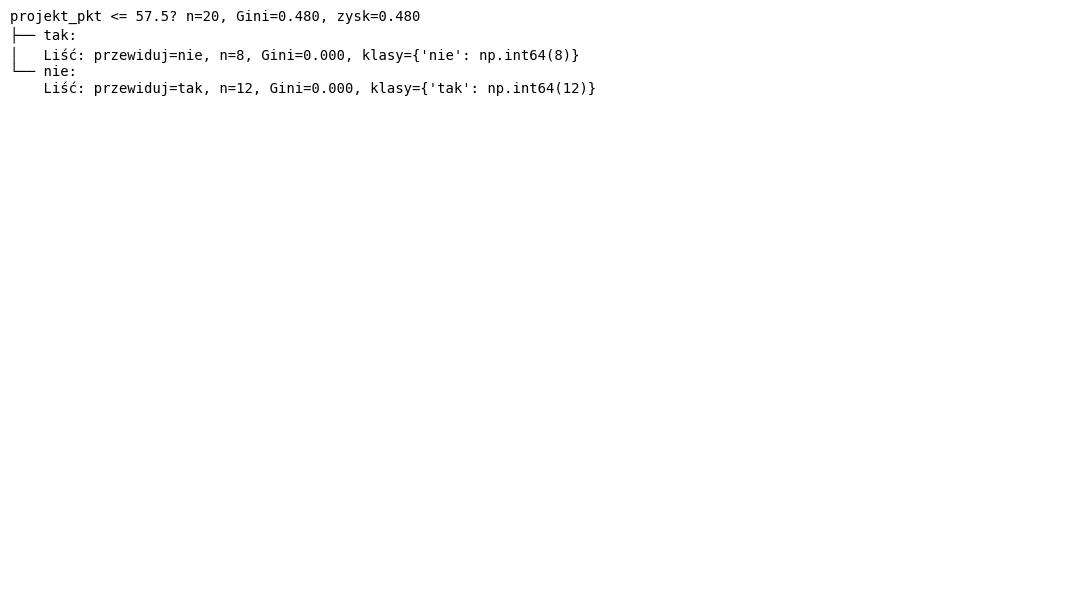

In [11]:
fig = plt.figure(figsize=(12, 7))
fig.text(0.02, 0.96, tree_text, va="top", family="monospace", fontsize=10)
plt.axis("off")
plt.savefig(ASSETS / "07_drzewo_od_zera_klasami.png", dpi=160, bbox_inches="tight")
plt.show()


## 11. Zadania dla studentów

1. Zmień `max_depth` na `1`, `2`, `3`, `4`. Kiedy drzewo zaczyna być trudne do opowiedzenia człowiekowi?
2. Dopisz parametr `min_samples_leaf`, żeby liść musiał mieć co najmniej kilka przykładów.
3. Zmień kryterium z Gini na entropię.
4. Dopisz metodę `predict_proba`, która zwraca proporcje klas w liściu.
5. Sprawdź, co się stanie, jeśli dodasz jedną zaszumioną cechę, np. `losowa_liczba`.
